# CDP 2019 Corporate Climate Change Disclosure — ESG Carbon Analysis

**Author:** Mingzhen (Chris) Gao  
**Data Source:** [CDP Unlocking Climate Solutions — Kaggle](https://www.kaggle.com/datasets/cdp-unlocking-climate-solutions)  
**Date:** May 2026

---

## Project Overview

This notebook performs a full ESG carbon emissions analysis using 2019 CDP (Carbon Disclosure Project) corporate climate data. The analysis covers:

1. **Data Collection & Cleaning** — Extract and clean Scope 1, 2, and 3 emissions from 965 companies
2. **Industry Benchmarking** — Sector-level median Scope 1 emissions comparison
3. **Intra-sector Company Ranking** — Identify top and bottom emitters within a sector
4. **Disclosure Gap Analysis** — Identify which companies avoid disclosing Scope 3
5. **Emissions Modeling** — Weighted emissions model, industry deviation model, and carbon intensity model (tCO2e / $M revenue)
6. **Data Quality Flagging** — Identify anomalous zero-emission reporters

> **Note on carbon intensity model:** Revenue data was fetched via `yfinance` for US-listed companies only (~372 of 965). Non-US tickers returned 404 errors and were set to `None`. Carbon intensity is therefore only available for the US subset.

> **Note on custom weights:** The weighted emissions model (Scope 1 × 0.5 + Scope 2 × 0.3 + Scope 3 × 0.2) is an exploratory assumption based on data quality differences across scopes. It does not reflect any official standard (GHG Protocol, CDP, GRI).

## 1. Setup & Data Loading

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import os

# Suppress minor warnings
import warnings
warnings.filterwarnings('ignore')

# Create output directories
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)
print('Output directories ready: figures/, results/')


Output directories ready: figures/, results/


In [14]:
# Update this path to match your local data directory
data_dir = 'Data/'

# Main questionnaire responses (long format, ~1.1M rows)
df_main = pd.read_feather(data_dir + '2019_Full_Climate_Change_Dataset.feather')

# Corporate metadata: sector, country, ticker
df_corp = pd.read_feather(data_dir + '2019_Corporates_Disclosing_to_CDP_Climate_Change.feather')

print('Main data shape:', df_main.shape)
print('Corporate info shape:', df_corp.shape)

Main data shape: (1125040, 20)
Corporate info shape: (965, 23)


## 2. Data Cleaning — Extract Scope 1, 2, 3 Emissions

The main dataset is in **long format**: each row is one company's answer to one question.

- **Scope 1** (direct emissions): `question_number == 'C6.1'`, `data_point_name` contains `'C6.1_C1'`
- **Scope 2** (purchased electricity, location-based): `question_number == 'C6.3'`, contains `'C6.3_C1'`
- **Scope 3** (value chain emissions): `question_number == 'C6.5'`, contains `'C6.5_C2'`

In [15]:
# --- Scope 1 ---
df_s1 = df_main[
    (df_main['question_number'] == 'C6.1') &
    (df_main['data_point_name'].str.contains('C6.1_C1'))
]
df_s1 = df_s1.copy()
df_s1['response_value'] = pd.to_numeric(df_s1['response_value'], errors='coerce')

# --- Scope 2 (location-based) ---
df_s2 = df_main[
    (df_main['question_number'] == 'C6.3') &
    (df_main['data_point_name'].str.contains('C6.3_C1'))
]
df_s2 = df_s2.copy()
df_s2['response_value'] = pd.to_numeric(df_s2['response_value'], errors='coerce')

# --- Scope 3 (metric tonnes CO2e) ---
df_s3 = df_main[
    (df_main['question_number'] == 'C6.5') &
    (df_main['data_point_name'].str.contains('C6.5_C2'))
]
df_s3 = df_s3.copy()
df_s3['response_value'] = pd.to_numeric(df_s3['response_value'], errors='coerce')

print('Scope 1 rows:', df_s1.shape[0])
print('Scope 2 rows:', df_s2.shape[0])
print('Scope 3 rows:', df_s3.shape[0])

Scope 1 rows: 3860
Scope 2 rows: 3860
Scope 3 rows: 16405


In [16]:
# Extract key columns and rename response_value to scope label
df_s1_key = df_s1.rename(columns={'response_value': 'scope1'})[['account_number', 'scope1']]
df_s2_key = df_s2.rename(columns={'response_value': 'scope2'})[['account_number', 'scope2']]
df_s3_key = df_s3.rename(columns={'response_value': 'scope3'})[['account_number', 'scope3']]

# Merge all three scopes, then average duplicates per company
df_scope = pd.merge(pd.merge(df_s1_key, df_s2_key, on='account_number'), df_s3_key, on='account_number')
df_scope = df_scope.groupby('account_number')[['scope1', 'scope2', 'scope3']].mean().reset_index()

# Merge with corporate metadata
df_scope = pd.merge(df_scope, df_corp, on='account_number')

print('Final emissions table shape:', df_scope.shape)
df_scope[['organization', 'scope1', 'scope2', 'scope3']].head()

Final emissions table shape: (965, 26)


,organization,scope1,scope2,scope3
0,ABM INDUSTRIES INC,49224.21,6622.38,3.202270e+03
1,Abbott Laboratories,518500.00,531500.00,1.379111e+03
2,Resolute Forest Products Inc.,1066050.50,1096161.00,5.126199e+05
3,3M Company,4790000.00,1860000.00,1.204450e+06
4,Abercrombie & Fitch Co.,8817.00,62744.00,6.013400e+04


## 3. Disclosure Gap Analysis

How many companies fail to report each scope? Scope 3 has the highest non-disclosure rate — it is the hardest to calculate and easiest to avoid.

scope1    200
scope2    280
scope3    415
dtype: int64


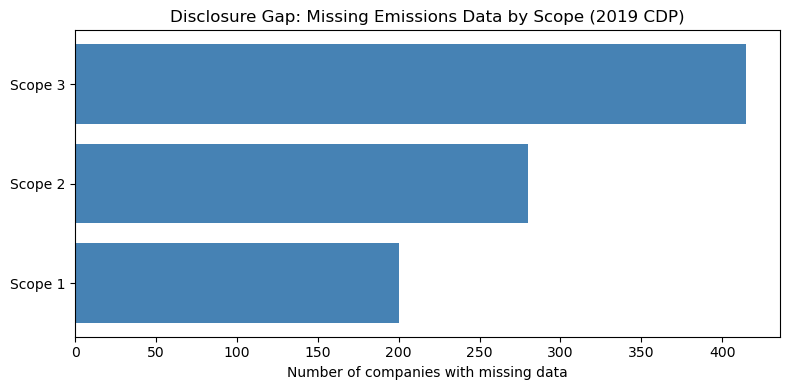

Saved: figures/fig1_disclosure_gap.png
Saved: results/disclosure_gap.csv


In [17]:
# Count missing values per scope
df_scope_abs = df_scope[['scope1', 'scope2', 'scope3']].isnull().sum()
print(df_scope_abs)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(['Scope 1', 'Scope 2', 'Scope 3'], df_scope_abs.values, color='steelblue')
ax.set_xlabel('Number of companies with missing data')
ax.set_title('Disclosure Gap: Missing Emissions Data by Scope (2019 CDP)')
plt.tight_layout()
plt.savefig('figures/fig1_disclosure_gap.png', dpi=150)
plt.show()
print('Saved: figures/fig1_disclosure_gap.png')

# Save disclosure gap table
df_scope_abs.to_frame('missing_count').to_csv('results/disclosure_gap.csv')
print('Saved: results/disclosure_gap.csv')


## 4. Emissions Modeling

Three complementary models are built:

| Model | Description |
|---|---|
| **Industry standard** | Scope 1 + Scope 2 combined (per GHG Protocol) |
| **Weighted model** | Scope1×0.5 + Scope2×0.3 + Scope3×0.2 (exploratory) |
| **Carbon intensity** | (Scope1+2) / Revenue × 1M (tCO2e per $M revenue) |

In [18]:
# Industry standard: Scope 1 + Scope 2
df_scope['scope1_2'] = df_scope[['scope1', 'scope2']].sum(axis=1)

# Weighted model (exploratory — not an official standard)
df_scope['scope_weighted'] = (
    0.5 * df_scope['scope1'] +
    0.3 * df_scope['scope2'] +
    0.2 * df_scope['scope3']
)

# Total emissions (Scope 1 + 2 + 3)
df_scope['total_emission'] = df_scope[['scope1', 'scope2', 'scope3']].sum(axis=1)

# Save full emissions table
df_scope[['organization', 'primary_sector', 'scope1', 'scope2', 'scope3',
           'scope1_2', 'scope_weighted', 'total_emission']].to_csv(
    'results/emissions_model.csv', index=False)
print('Saved: results/emissions_model.csv')

df_scope[['organization', 'scope1_2', 'scope_weighted', 'total_emission']].head()


Saved: results/emissions_model.csv


,organization,scope1_2,scope_weighted,total_emission
0,ABM INDUSTRIES INC,55846.59,2.723927e+04,5.904886e+04
1,Abbott Laboratories,1050000.00,4.189758e+05,1.051379e+06
2,Resolute Forest Products Inc.,2162211.50,9.643975e+05,2.674831e+06
3,3M Company,6650000.00,3.193890e+06,7.854450e+06
4,Abercrombie & Fitch Co.,71561.00,3.525850e+04,1.316950e+05


## 5. Industry Benchmarking — Sector Median Scope 1 Emissions

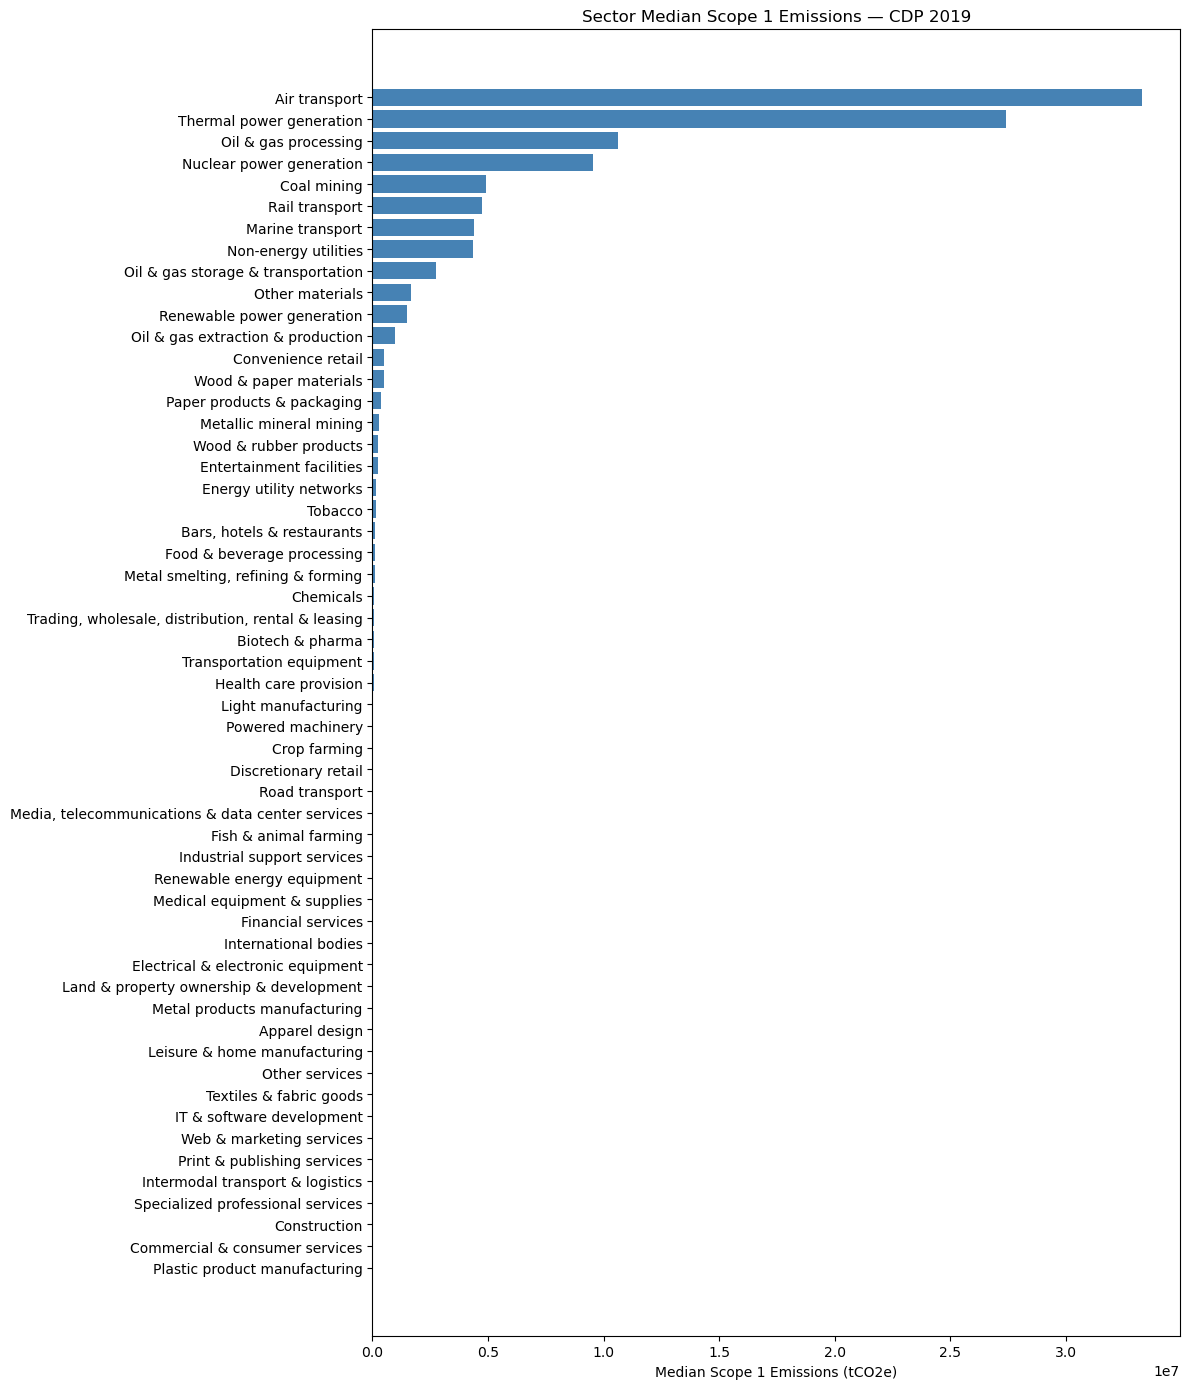

Saved: figures/fig2_sector_benchmark.png
Saved: results/sector_benchmark.csv


In [19]:
# Merge Scope 1 with sector info for benchmarking
df_merged = pd.merge(df_s1, df_corp, on='account_number')
df_merged['response_value'] = pd.to_numeric(df_merged['response_value'], errors='coerce')

# Sector median
sector_median = df_merged.groupby('primary_sector')['response_value'].median()
sector_median = sector_median.sort_values(ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 14))
ax.barh(sector_median.index, sector_median.values, color='steelblue')
ax.set_xlabel('Median Scope 1 Emissions (tCO2e)')
ax.set_title('Sector Median Scope 1 Emissions — CDP 2019')
plt.tight_layout()
plt.savefig('figures/fig2_sector_benchmark.png', dpi=150)
plt.show()
print('Saved: figures/fig2_sector_benchmark.png')

# Save sector benchmark table
sector_median.to_frame('median_scope1_tco2e').to_csv('results/sector_benchmark.csv')
print('Saved: results/sector_benchmark.csv')


## 6. Intra-sector Company Ranking — Electrical & Electronic Equipment

Tesla is notably absent from this dataset — the company did not disclose to CDP in 2019, which is itself an ESG finding.

In [20]:
df_elec = df_merged[df_merged['primary_sector'] == 'Electrical & electronic equipment']
df_elec_ranked = (
    df_elec[['organization_x', 'response_value']]
    .groupby('organization_x')['response_value'].mean()
    .sort_values(ascending=False)
)

print('Top 10 highest Scope 1 emitters — Electrical & Electronic:')
print(df_elec_ranked.head(10))

print('\nTesla disclosure check:')
print(df_elec_ranked[df_elec_ranked.index.str.contains('Tesla')])

# Save intra-sector ranking
df_elec_ranked.to_frame('scope1_tco2e').to_csv('results/intra_sector_ranking_electrical.csv')
print('\nSaved: results/intra_sector_ranking_electrical.csv')


Top 10 highest Scope 1 emitters — Electrical & Electronic:
organization_x
Micron Technology, Inc.               2945735.0
Honeywell International Inc.          1479149.0
ON Semiconductor                      1470613.0
Intel Corporation                     1458000.0
Texas Instruments Incorporated        1157555.0
Johnson Controls International PLC    1032520.0
United Technologies Corporation        796383.0
Microchip Technology                   529371.0
Eaton Corporation                      297169.0
Lockheed Martin Corporation            291522.0
Name: response_value, dtype: float64

Tesla disclosure check:
Series([], Name: response_value, dtype: float64)

Saved: results/intra_sector_ranking_electrical.csv


## 7. Industry Deviation Model

For each company, calculate how far its Scope 1+2 emissions deviate from its sector average.  
Positive = above average (higher risk); Negative = below average (better performer).

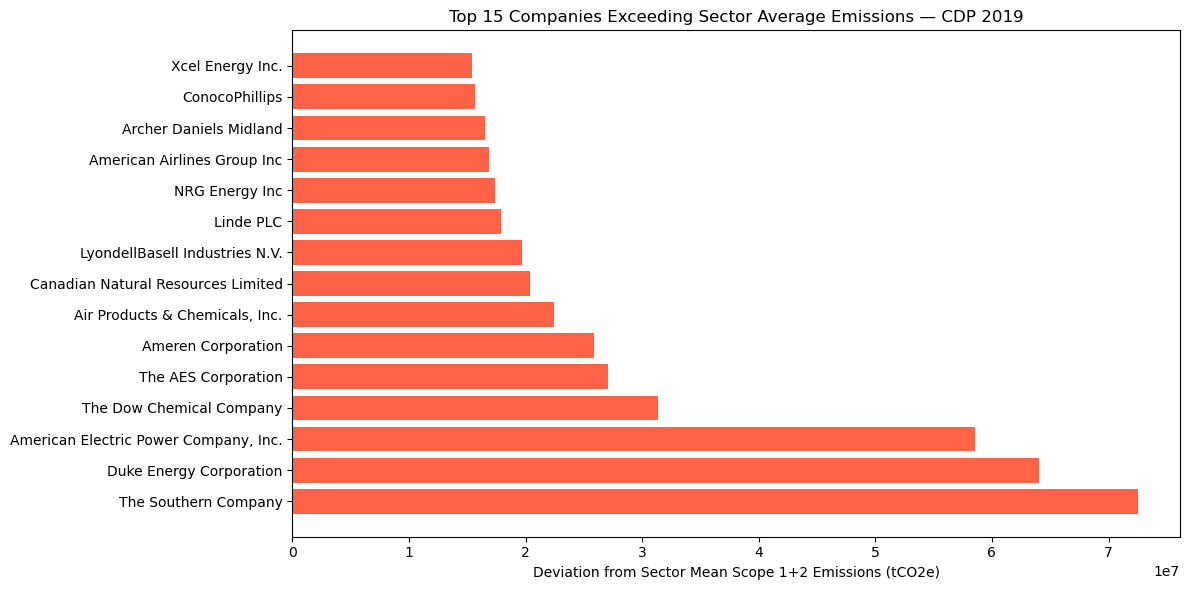

Saved: figures/fig3_industry_deviation.png
Saved: results/industry_deviation.csv


In [21]:
# Sector mean of Scope 1+2
industry_mean = df_scope.groupby('primary_sector')['scope1_2'].mean()
industry_mean = industry_mean.rename('industry_mean_scope1_2')

# Merge back to get company-level deviation
df_scope = pd.merge(df_scope, industry_mean, on='primary_sector')
df_scope['deviation'] = df_scope['scope1_2'] - df_scope['industry_mean_scope1_2']

# Top 15 companies above sector average
top15_dev = (
    df_scope[['organization', 'deviation']]
    .sort_values('deviation', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top15_dev['organization'], top15_dev['deviation'], color='tomato')
ax.set_xlabel('Deviation from Sector Mean Scope 1+2 Emissions (tCO2e)')
ax.set_title('Top 15 Companies Exceeding Sector Average Emissions — CDP 2019')
plt.tight_layout()
plt.savefig('figures/fig3_industry_deviation.png', dpi=150)
plt.show()
print('Saved: figures/fig3_industry_deviation.png')

# Save full deviation table
df_scope[['organization', 'primary_sector', 'scope1_2', 'industry_mean_scope1_2', 'deviation']]\
    .sort_values('deviation', ascending=False)\
    .to_csv('results/industry_deviation.csv', index=False)
print('Saved: results/industry_deviation.csv')


## 8. Carbon Intensity Model

Carbon intensity = Scope 1+2 emissions / Revenue × 1,000,000  
Unit: **tCO2e per $M revenue**

Revenue data is fetched from Yahoo Finance via `yfinance`. Only US-listed companies with valid tickers are included (~372 of 965 companies).

In [22]:
# Clean ticker: remove exchange suffix (e.g. 'ABM US' -> 'ABM')
df_scope['ticker'] = df_scope['primary_ticker'].str.replace(' US', '')

# Fetch revenue data from Yahoo Finance
# Note: non-US tickers will return 404 and be stored as None
revenues = {}
for ticker in df_scope['ticker']:
    try:
        revenues[ticker] = yf.Ticker(ticker).info['totalRevenue']
    except:
        revenues[ticker] = None

# Filter successful lookups
revenues_success = {k: v for k, v in revenues.items() if v is not None}
print(f'Revenue data retrieved for {len(revenues_success)} of {len(revenues)} companies')

# Convert to DataFrame
df_revenues = pd.Series(revenues_success).reset_index()
df_revenues.columns = ['ticker', 'revenue']

# Merge and calculate carbon intensity
df_scope = pd.merge(df_scope, df_revenues, on='ticker')
df_scope['co2_intensity'] = df_scope['scope1_2'] / df_scope['revenue'] * 1_000_000

df_scope[['organization', 'scope1_2', 'revenue', 'co2_intensity']].head()

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AEM CN"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AC CN"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AQN CN"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ALA CN"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ARX CN"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ATA CN"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: BMO CN"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote no

Revenue data retrieved for 372 of 600 companies


,organization,scope1_2,revenue,co2_intensity
0,ABM INDUSTRIES INC,55846.59,8874500096,6.292928
1,Abbott Laboratories,1050000.00,45134000128,23.264058
2,3M Company,6650000.00,25024000000,265.744885
3,Abercrombie & Fitch Co.,71561.00,5266292224,13.588498
4,The AES Corporation,59632787.00,12487000064,4775.589549


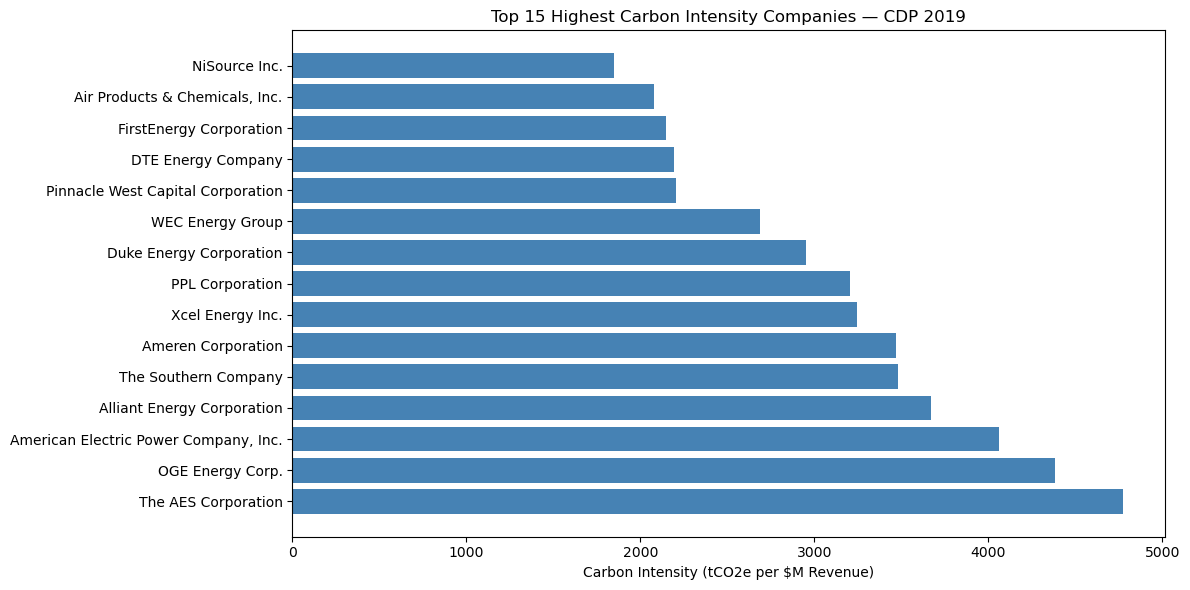

Saved: figures/fig4_carbon_intensity.png
Saved: results/carbon_intensity.csv


In [23]:
# Top 15 highest carbon intensity companies
top15_co2 = (
    df_scope[['organization', 'co2_intensity']]
    .sort_values('co2_intensity', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top15_co2['organization'], top15_co2['co2_intensity'], color='steelblue')
ax.set_xlabel('Carbon Intensity (tCO2e per $M Revenue)')
ax.set_title('Top 15 Highest Carbon Intensity Companies — CDP 2019')
plt.tight_layout()
plt.savefig('figures/fig4_carbon_intensity.png', dpi=150)
plt.show()
print('Saved: figures/fig4_carbon_intensity.png')

# Save carbon intensity table
df_scope[['organization', 'primary_sector', 'scope1_2', 'revenue', 'co2_intensity']]\
    .sort_values('co2_intensity', ascending=False)\
    .to_csv('results/carbon_intensity.csv', index=False)
print('Saved: results/carbon_intensity.csv')


## 9. Data Quality Flags — Anomalous Zero Reporters

15 companies report Scope 1+2 = 0. While plausible for pure financial services firms, some (e.g. Atmos Energy, a natural gas company) are clearly anomalous and warrant further investigation.

In [24]:
zero_reporters = df_scope[df_scope['co2_intensity'] == 0][
    ['organization', 'scope1_2', 'revenue', 'co2_intensity', 'primary_sector']]
print(f'Companies reporting Scope 1+2 = 0: {len(zero_reporters)}')

# Save zero reporters table
zero_reporters.to_csv('results/zero_reporters.csv', index=False)
print('Saved: results/zero_reporters.csv')

zero_reporters


Companies reporting Scope 1+2 = 0: 15
Saved: results/zero_reporters.csv


,organization,scope1_2,revenue,co2_intensity,primary_sector
33,Atmos Energy Corp,0.0,4881241088,0.0,Energy utility networks
71,"comScore, Inc.",0.0,357468992,0.0,IT & software development
85,Dentsply Sirona Inc.,0.0,3680999936,0.0,Medical equipment & supplies
105,Fidelity National Information Services,0.0,11440000000,0.0,Specialized professional services
168,MDU Resources Group Inc,0.0,1806265984,0.0,Construction
211,Ralph Lauren Corporation,0.0,7833099776,0.0,Discretionary retail
232,SEI Investments Company,0.0,2368219904,0.0,Financial services
300,Valmont Inc,0.0,4163984896,0.0,Metal products manufacturing
318,"Cadence Design Systems, Inc.",0.0,5528612864,0.0,IT & software development
331,"RPM International, Inc.",0.0,7713562112,0.0,Chemicals


## Summary of Findings

| Finding | Detail |
|---|---|
| **Scope 3 has largest disclosure gap** | 415 missing vs 200 (Scope 1) and 280 (Scope 2) |
| **Tesla did not disclose to CDP in 2019** | Absent from the entire dataset |
| **Highest Scope 1 sector** | Air transport and thermal power generation |
| **Highest carbon intensity companies** | All major US electric utilities (AES, OGE, AEP) |
| **Data quality flags** | 15 companies report Scope 1+2 = 0, including Atmos Energy (gas company) |

---
*Data source: CDP 2019 Full Climate Change Dataset via Kaggle. Revenue data sourced from Yahoo Finance (yfinance) for US-listed companies only.*